# SMHI Snow Depth Data Exploration

**Nordic Snow Monitoring Project**

This notebook explores the SMHI snow depth dataset downloaded for the multi-task deep learning model.

## Contents
1. [Data Loading & Overview](#1-data-loading--overview)
2. [Snow Depth Statistics](#2-snow-depth-statistics)
3. [Temporal Patterns](#3-temporal-patterns)
4. [Spatial Distribution](#4-spatial-distribution)
5. [Data Quality Analysis](#5-data-quality-analysis)
6. [Extreme Events Analysis](#6-extreme-events-analysis)
7. [Train/Val/Test Split Preview](#7-trainvaltest-split-preview)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72', 
    'accent': '#F18F01',
    'snow': '#4ECDC4',
    'cold': '#1A535C'
}

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## 1. Data Loading & Overview

In [2]:
# Load the data
df = pd.read_csv('../data/raw/smhi_snow.csv')
df['date'] = pd.to_datetime(df['date'])

# Add temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['week'] = df['date'].dt.isocalendar().week

print(f"Data loaded: {len(df):,} records")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Stations: {df['station_name'].nunique()}")

Data loaded: 1,349,161 records
Date range: 2015-01-01 to 2023-12-31
Stations: 602


In [3]:
# Display basic info
print("DataFrame Info:")
print("="*50)
df.info()
print("\nFirst 5 rows:")
df.head()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349161 entries, 0 to 1349160
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   date           1349161 non-null  datetime64[ns]
 1   time           1349161 non-null  object        
 2   snow_depth     1349161 non-null  float64       
 3   quality        1349161 non-null  object        
 4   station_id     1349161 non-null  int64         
 5   station_name   1349161 non-null  object        
 6   snow_depth_cm  1349161 non-null  float64       
 7   latitude       1349161 non-null  float64       
 8   longitude      1349161 non-null  float64       
 9   year           1349161 non-null  int32         
 10  month          1349161 non-null  int32         
 11  day_of_year    1349161 non-null  int32         
 12  week           1349161 non-null  UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(4), int32(3), int64(1), object

,date,time,snow_depth,quality,station_id,station_name,snow_depth_cm,latitude,longitude,year,month,day_of_year,week
0,2015-01-01,06:00:00,0.71,G,188800,Abisko,71.0,68.3538,18.8166,2015,1,1,1
1,2015-01-02,06:00:00,0.69,G,188800,Abisko,69.0,68.3538,18.8166,2015,1,2,1
2,2015-01-05,06:00:00,0.69,G,188800,Abisko,69.0,68.3538,18.8166,2015,1,5,2
3,2015-01-07,06:00:00,0.69,G,188800,Abisko,69.0,68.3538,18.8166,2015,1,7,2
4,2015-01-08,06:00:00,0.67,G,188800,Abisko,67.0,68.3538,18.8166,2015,1,8,2


In [4]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,date,snow_depth,station_id,snow_depth_cm,latitude,longitude,year,month,day_of_year,week
count,1349161,1.349161e+06,1.349161e+06,1.349161e+06,1.349161e+06,1.349161e+06,1.349161e+06,1.349161e+06,1.349161e+06,1349161.0
mean,2019-07-18 21:10:58.721383424,8.121124e-02,1.058841e+05,8.121124e+00,6.049858e+01,1.591298e+01,2.019046e+03,6.521423e+00,1.830557e+02,26.62455
min,2015-01-01 00:00:00,-2.000000e-02,5.223000e+04,-2.000000e+00,5.535940e+01,1.117870e+01,2.015000e+03,1.000000e+00,1.000000e+00,1.0
25%,2017-04-26 00:00:00,0.000000e+00,7.616000e+04,0.000000e+00,5.779380e+01,1.385290e+01,2.017000e+03,4.000000e+00,9.200000e+01,14.0
50%,2019-07-30 00:00:00,0.000000e+00,9.655000e+04,0.000000e+00,5.957930e+01,1.553040e+01,2.019000e+03,7.000000e+00,1.830000e+02,27.0
75%,2021-10-09 00:00:00,0.000000e+00,1.340700e+05,0.000000e+00,6.316810e+01,1.741460e+01,2.021000e+03,1.000000e+01,2.740000e+02,40.0
max,2023-12-31 00:00:00,2.290000e+00,1.937300e+05,2.290000e+02,6.880320e+01,2.411200e+01,2.023000e+03,1.200000e+01,3.660000e+02,53.0
std,NaN,2.017785e-01,3.512490e+04,2.017785e+01,3.323256e+00,2.722583e+00,2.565781e+00,3.445395e+00,1.053033e+02,15.043424


---
## 2. Snow Depth Statistics

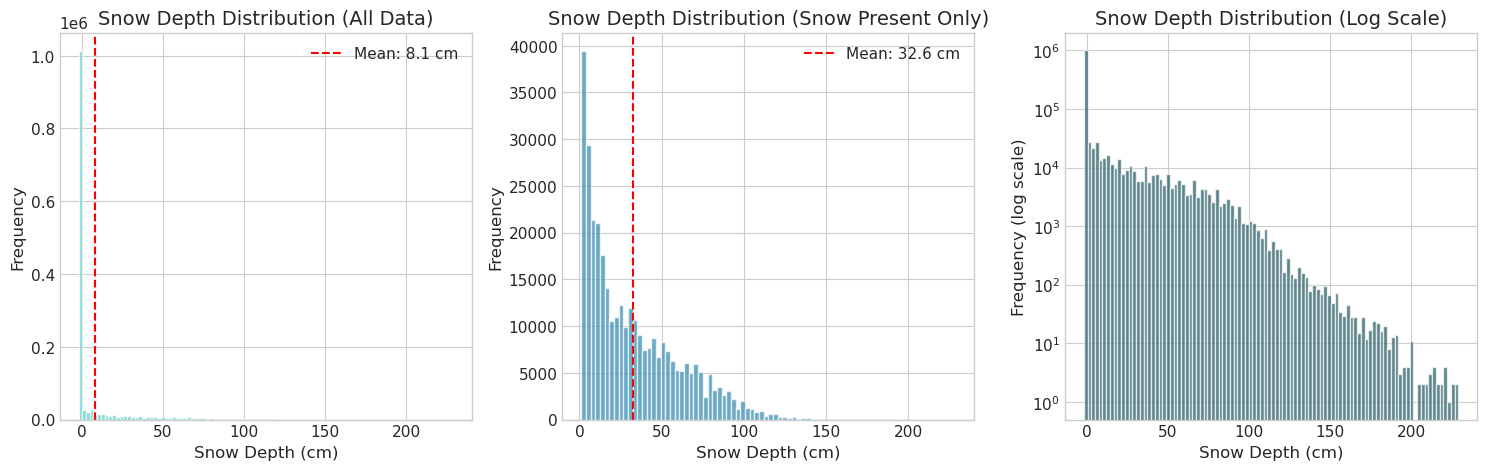


Snow Depth Statistics:
  Total records: 1,349,161
  Records with snow (>0): 336,071 (24.9%)
  Mean (all): 8.1 cm
  Mean (snow present): 32.6 cm
  Max: 229.0 cm
  95th percentile: 58.0 cm


In [5]:
# Snow depth distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# All data
ax1 = axes[0]
ax1.hist(df['snow_depth_cm'], bins=100, color=COLORS['snow'], edgecolor='white', alpha=0.7)
ax1.set_xlabel('Snow Depth (cm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Snow Depth Distribution (All Data)')
ax1.axvline(df['snow_depth_cm'].mean(), color='red', linestyle='--', label=f"Mean: {df['snow_depth_cm'].mean():.1f} cm")
ax1.legend()

# Non-zero only
ax2 = axes[1]
non_zero = df[df['snow_depth_cm'] > 0]['snow_depth_cm']
ax2.hist(non_zero, bins=80, color=COLORS['primary'], edgecolor='white', alpha=0.7)
ax2.set_xlabel('Snow Depth (cm)')
ax2.set_ylabel('Frequency')
ax2.set_title('Snow Depth Distribution (Snow Present Only)')
ax2.axvline(non_zero.mean(), color='red', linestyle='--', label=f"Mean: {non_zero.mean():.1f} cm")
ax2.legend()

# Log scale for extreme values
ax3 = axes[2]
ax3.hist(df['snow_depth_cm'], bins=100, color=COLORS['cold'], edgecolor='white', alpha=0.7, log=True)
ax3.set_xlabel('Snow Depth (cm)')
ax3.set_ylabel('Frequency (log scale)')
ax3.set_title('Snow Depth Distribution (Log Scale)')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nSnow Depth Statistics:")
print(f"  Total records: {len(df):,}")
print(f"  Records with snow (>0): {len(non_zero):,} ({100*len(non_zero)/len(df):.1f}%)")
print(f"  Mean (all): {df['snow_depth_cm'].mean():.1f} cm")
print(f"  Mean (snow present): {non_zero.mean():.1f} cm")
print(f"  Max: {df['snow_depth_cm'].max():.1f} cm")
print(f"  95th percentile: {df['snow_depth_cm'].quantile(0.95):.1f} cm")

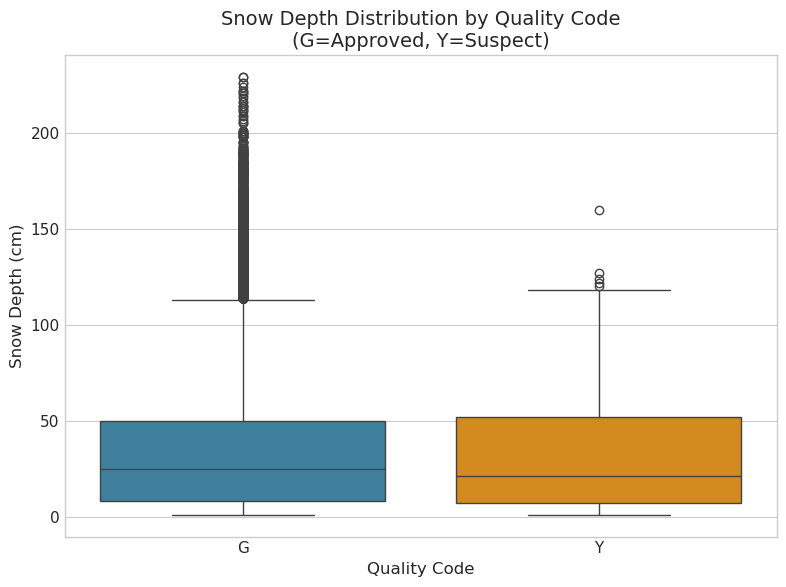


Quality Code Breakdown:
  G: 1,167,213 records (86.5%)
  Y: 181,948 records (13.5%)


In [6]:
# Box plot by quality code
fig, ax = plt.subplots(figsize=(8, 6))

df_nonzero = df[df['snow_depth_cm'] > 0]
sns.boxplot(data=df_nonzero, x='quality', y='snow_depth_cm', palette=[COLORS['primary'], COLORS['accent']], ax=ax)
ax.set_xlabel('Quality Code')
ax.set_ylabel('Snow Depth (cm)')
ax.set_title('Snow Depth Distribution by Quality Code\n(G=Approved, Y=Suspect)')

plt.tight_layout()
plt.show()

# Quality code statistics
print("\nQuality Code Breakdown:")
for q in df['quality'].unique():
    q_data = df[df['quality'] == q]
    print(f"  {q}: {len(q_data):,} records ({100*len(q_data)/len(df):.1f}%)")

---
## 3. Temporal Patterns

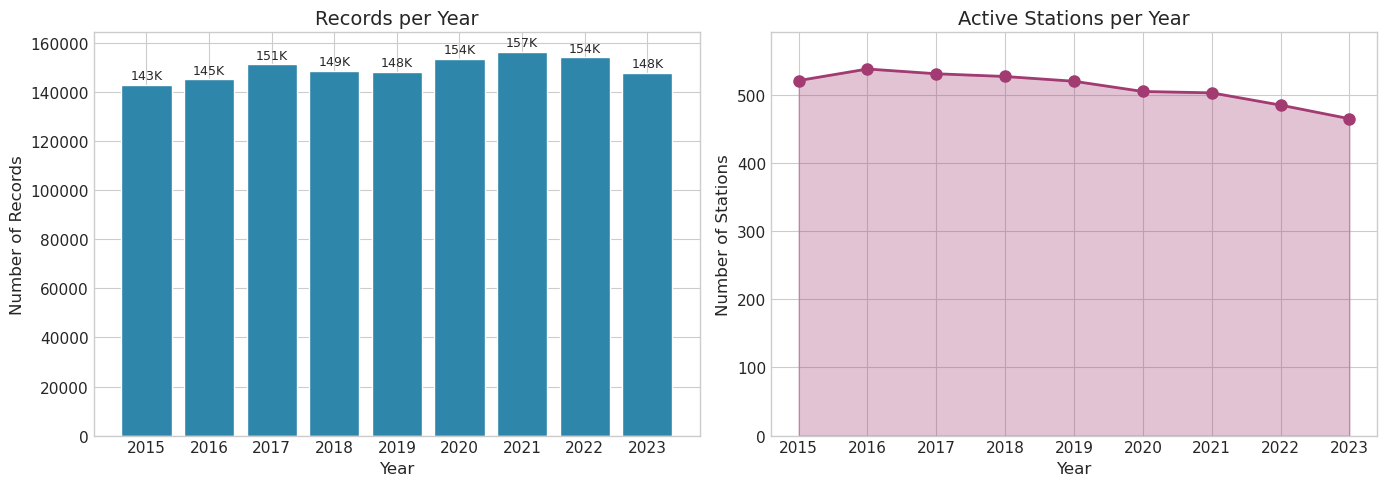

In [7]:
# Records and stations per year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records per year
yearly_records = df.groupby('year').size()
ax1 = axes[0]
bars = ax1.bar(yearly_records.index, yearly_records.values, color=COLORS['primary'], edgecolor='white')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Records')
ax1.set_title('Records per Year')
ax1.set_xticks(yearly_records.index)
for bar, val in zip(bars, yearly_records.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, f'{val/1000:.0f}K', 
             ha='center', va='bottom', fontsize=9)

# Stations per year
yearly_stations = df.groupby('year')['station_name'].nunique()
ax2 = axes[1]
ax2.plot(yearly_stations.index, yearly_stations.values, marker='o', linewidth=2, 
         markersize=8, color=COLORS['secondary'])
ax2.fill_between(yearly_stations.index, yearly_stations.values, alpha=0.3, color=COLORS['secondary'])
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Stations')
ax2.set_title('Active Stations per Year')
ax2.set_xticks(yearly_stations.index)
ax2.set_ylim(0, yearly_stations.max() * 1.1)

plt.tight_layout()
plt.show()

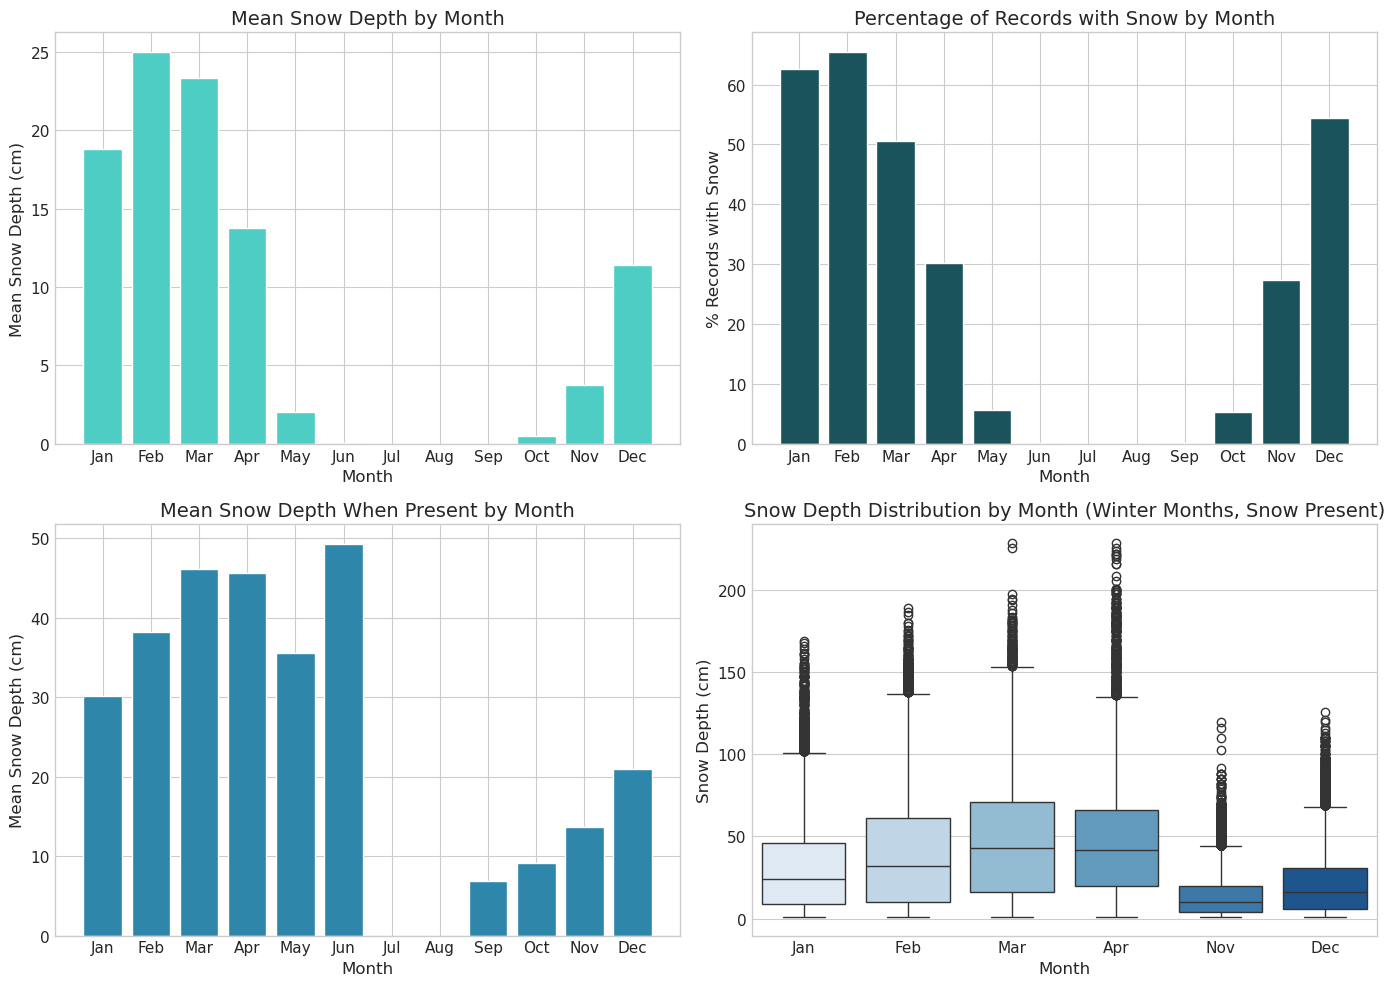

In [8]:
# Monthly patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Mean snow depth by month
ax1 = axes[0, 0]
monthly_mean = df.groupby('month')['snow_depth_cm'].mean()
bars = ax1.bar(range(1, 13), monthly_mean.values, color=COLORS['snow'], edgecolor='white')
ax1.set_xlabel('Month')
ax1.set_ylabel('Mean Snow Depth (cm)')
ax1.set_title('Mean Snow Depth by Month')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months)

# Percentage with snow by month
ax2 = axes[0, 1]
monthly_pct = df.groupby('month').apply(lambda x: 100 * (x['snow_depth_cm'] > 0).mean())
ax2.bar(range(1, 13), monthly_pct.values, color=COLORS['cold'], edgecolor='white')
ax2.set_xlabel('Month')
ax2.set_ylabel('% Records with Snow')
ax2.set_title('Percentage of Records with Snow by Month')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(months)

# Mean snow depth when present by month
ax3 = axes[1, 0]
monthly_mean_present = df[df['snow_depth_cm'] > 0].groupby('month')['snow_depth_cm'].mean()
ax3.bar(monthly_mean_present.index, monthly_mean_present.values, color=COLORS['primary'], edgecolor='white')
ax3.set_xlabel('Month')
ax3.set_ylabel('Mean Snow Depth (cm)')
ax3.set_title('Mean Snow Depth When Present by Month')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(months)

# Box plot by month (snow present only)
ax4 = axes[1, 1]
df_winter = df[(df['month'].isin([1, 2, 3, 4, 11, 12])) & (df['snow_depth_cm'] > 0)]
sns.boxplot(data=df_winter, x='month', y='snow_depth_cm', ax=ax4, palette='Blues')
ax4.set_xlabel('Month')
ax4.set_ylabel('Snow Depth (cm)')
ax4.set_title('Snow Depth Distribution by Month (Winter Months, Snow Present)')
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

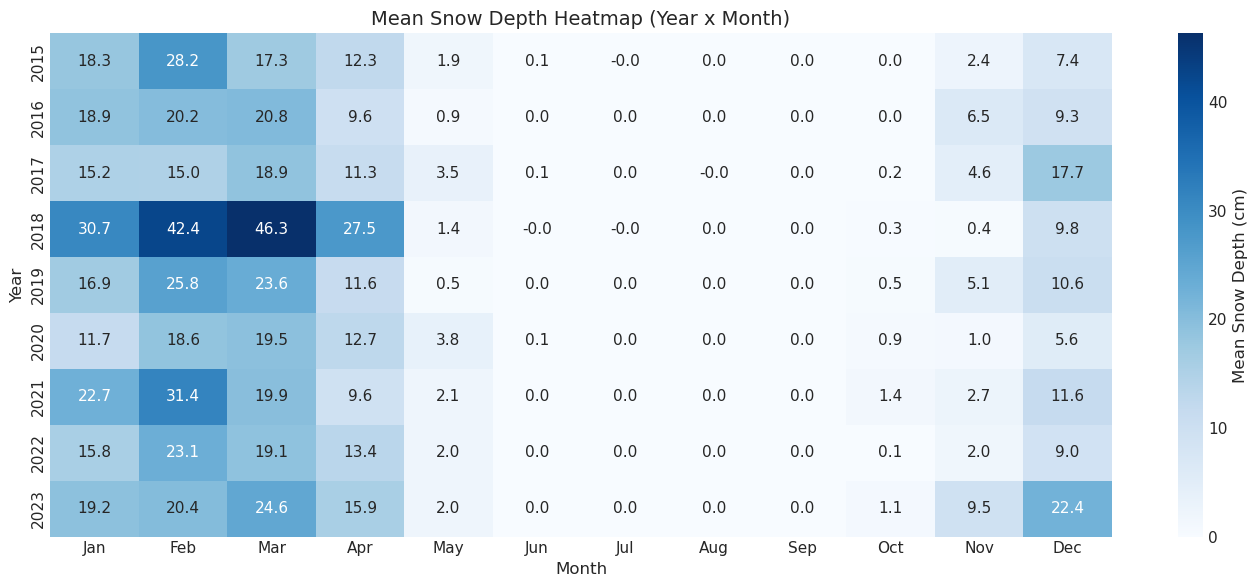

In [9]:
# Seasonal heatmap - Mean snow depth by year and month
fig, ax = plt.subplots(figsize=(14, 6))

pivot = df.pivot_table(values='snow_depth_cm', index='year', columns='month', aggfunc='mean')
pivot.columns = months

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', ax=ax, cbar_kws={'label': 'Mean Snow Depth (cm)'})
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_title('Mean Snow Depth Heatmap (Year x Month)')

plt.tight_layout()
plt.show()

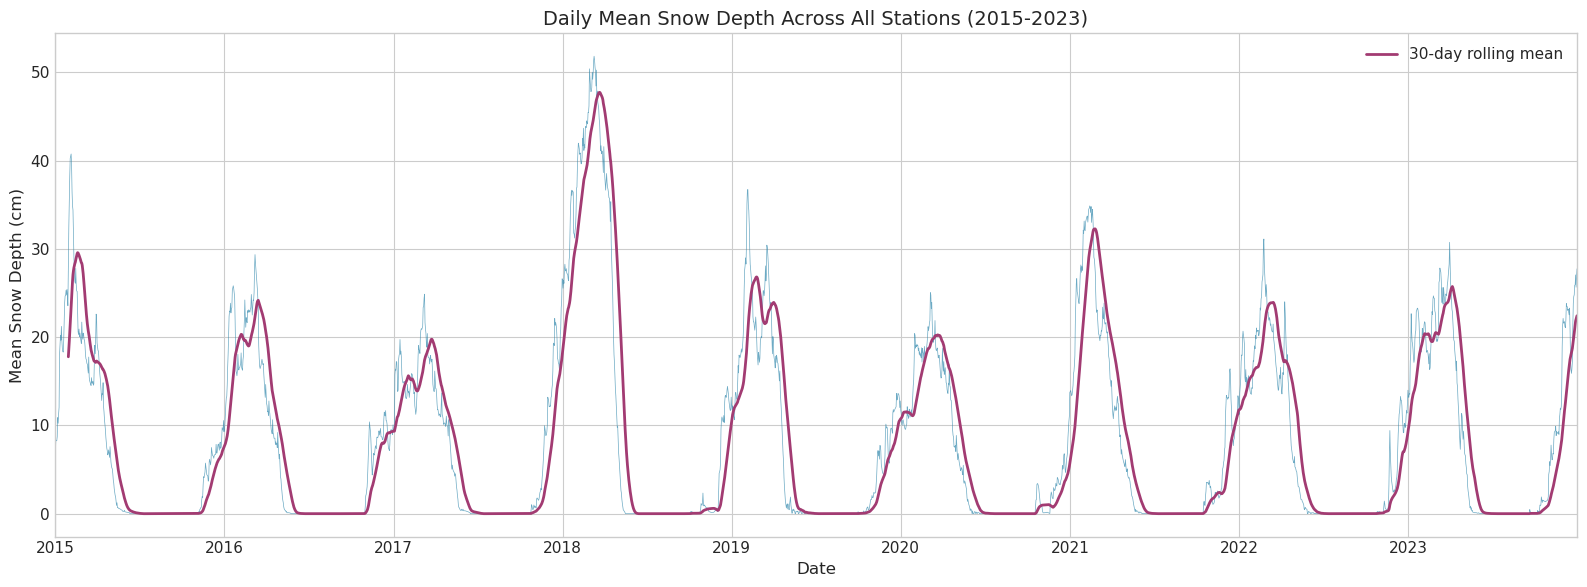

In [10]:
# Time series of daily mean snow depth
fig, ax = plt.subplots(figsize=(16, 6))

daily_mean = df.groupby('date')['snow_depth_cm'].mean()
ax.plot(daily_mean.index, daily_mean.values, linewidth=0.5, color=COLORS['primary'], alpha=0.7)

# Add rolling mean
rolling = daily_mean.rolling(window=30).mean()
ax.plot(rolling.index, rolling.values, linewidth=2, color=COLORS['secondary'], label='30-day rolling mean')

ax.set_xlabel('Date')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Daily Mean Snow Depth Across All Stations (2015-2023)')
ax.legend()
ax.set_xlim(daily_mean.index.min(), daily_mean.index.max())

plt.tight_layout()
plt.show()

---
## 4. Spatial Distribution

In [11]:
# Station locations and statistics
stations = df.groupby('station_name').agg({
    'latitude': 'first',
    'longitude': 'first',
    'snow_depth_cm': ['count', 'mean', 'max', 'std'],
    'date': ['min', 'max']
}).reset_index()
stations.columns = ['station', 'lat', 'lon', 'n_records', 'mean_snow', 'max_snow', 'std_snow', 'first_date', 'last_date']

print(f"Station Statistics:")
print(f"  Total stations: {len(stations)}")
print(f"  Latitude range: {stations['lat'].min():.2f}°N to {stations['lat'].max():.2f}°N")
print(f"  Longitude range: {stations['lon'].min():.2f}°E to {stations['lon'].max():.2f}°E")
stations.head(10)

Station Statistics:
  Total stations: 602
  Latitude range: 55.36°N to 68.80°N
  Longitude range: 11.18°E to 24.11°E


,station,lat,lon,n_records,mean_snow,max_snow,std_snow,first_date,last_date
0,Abisko,68.3538,18.8166,1860,25.330645,127.0,33.299315,2015-01-01,2022-03-01
1,Abisko Aut,68.3538,18.8164,582,25.254296,101.0,26.955320,2021-12-17,2023-12-31
2,Abraur,65.9857,18.9195,3250,28.437846,112.0,31.900208,2015-01-01,2023-12-31
3,Adak,65.3530,18.5837,3163,33.982611,120.0,38.244768,2015-01-01,2023-12-27
4,Alingsås D,57.8939,12.5472,3281,0.658031,26.0,2.691241,2015-01-01,2023-12-31
5,Almdalen,63.9967,14.6701,1370,5.424088,179.0,23.756935,2015-01-22,2023-12-31
6,Almunge,59.9334,18.0446,50,0.780000,22.0,3.726847,2015-05-01,2017-01-31
7,Andersviksberg,60.3694,13.8749,1,1.000000,1.0,NaN,2016-02-07,2016-02-07
8,Ankarsrum D,57.6784,16.1930,2664,1.781532,65.0,6.460163,2016-09-01,2023-12-31
9,Ankarvattnet D,64.8594,14.2562,2543,25.889501,130.0,35.339168,2015-01-01,2023-12-31


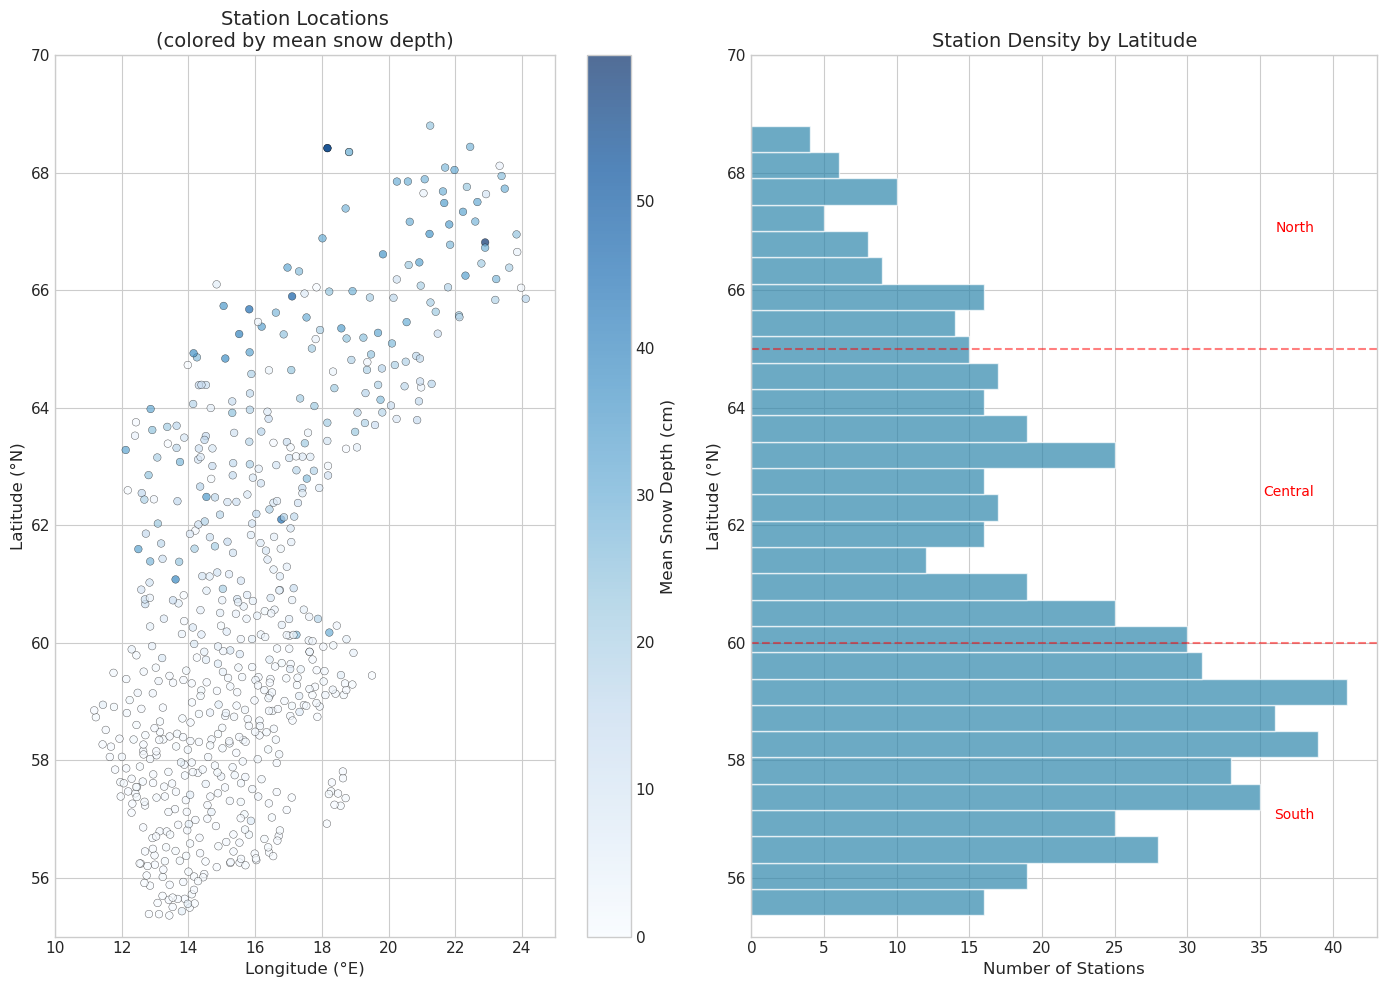

In [12]:
# Map of station locations colored by mean snow depth
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Station locations
ax1 = axes[0]
scatter = ax1.scatter(stations['lon'], stations['lat'], c=stations['mean_snow'], 
                      cmap='Blues', s=30, alpha=0.7, edgecolors='black', linewidths=0.3)
ax1.set_xlabel('Longitude (°E)')
ax1.set_ylabel('Latitude (°N)')
ax1.set_title('Station Locations\n(colored by mean snow depth)')
plt.colorbar(scatter, ax=ax1, label='Mean Snow Depth (cm)')

# Add Sweden approximate border
ax1.set_xlim(10, 25)
ax1.set_ylim(55, 70)

# Station density by latitude
ax2 = axes[1]
ax2.hist(stations['lat'], bins=30, orientation='horizontal', color=COLORS['primary'], edgecolor='white', alpha=0.7)
ax2.set_ylabel('Latitude (°N)')
ax2.set_xlabel('Number of Stations')
ax2.set_title('Station Density by Latitude')
ax2.set_ylim(55, 70)

# Add region labels
ax2.axhline(y=65, color='red', linestyle='--', alpha=0.5)
ax2.axhline(y=60, color='red', linestyle='--', alpha=0.5)
ax2.text(ax2.get_xlim()[1]*0.9, 67, 'North', ha='right', fontsize=10, color='red')
ax2.text(ax2.get_xlim()[1]*0.9, 62.5, 'Central', ha='right', fontsize=10, color='red')
ax2.text(ax2.get_xlim()[1]*0.9, 57, 'South', ha='right', fontsize=10, color='red')

plt.tight_layout()
plt.show()

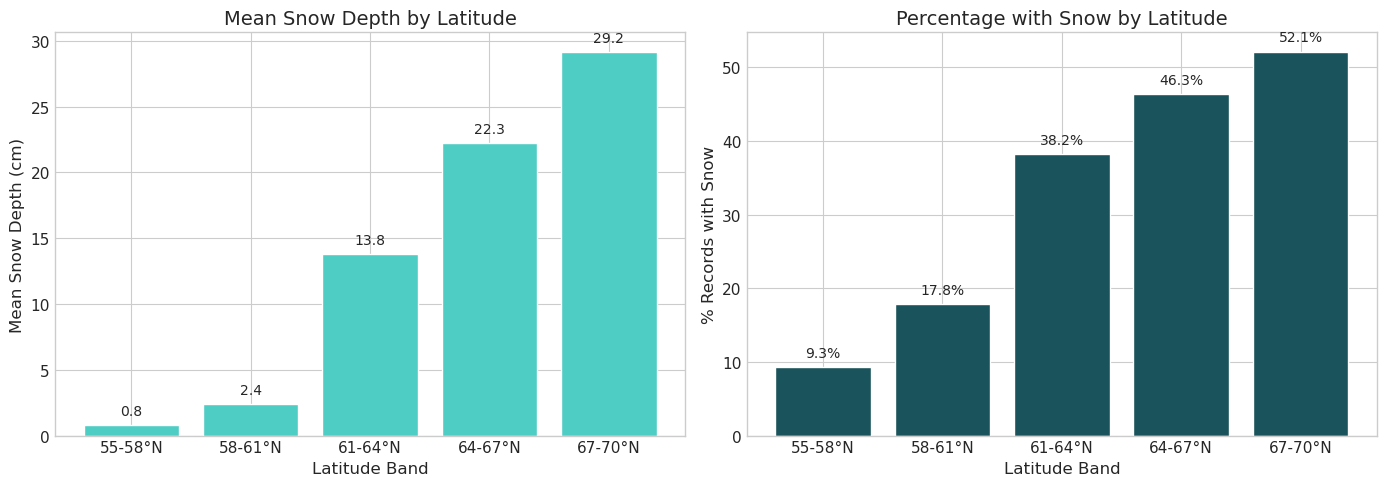

In [13]:
# Snow depth by latitude band
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create latitude bands
df['lat_band'] = pd.cut(df['latitude'], bins=[55, 58, 61, 64, 67, 70], 
                        labels=['55-58°N', '58-61°N', '61-64°N', '64-67°N', '67-70°N'])

# Mean snow depth by latitude band
ax1 = axes[0]
lat_mean = df.groupby('lat_band')['snow_depth_cm'].mean()
bars = ax1.bar(range(len(lat_mean)), lat_mean.values, color=COLORS['snow'], edgecolor='white')
ax1.set_xlabel('Latitude Band')
ax1.set_ylabel('Mean Snow Depth (cm)')
ax1.set_title('Mean Snow Depth by Latitude')
ax1.set_xticks(range(len(lat_mean)))
ax1.set_xticklabels(lat_mean.index)
for bar, val in zip(bars, lat_mean.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=10)

# Percentage with snow by latitude band
ax2 = axes[1]
lat_pct = df.groupby('lat_band').apply(lambda x: 100 * (x['snow_depth_cm'] > 0).mean())
bars = ax2.bar(range(len(lat_pct)), lat_pct.values, color=COLORS['cold'], edgecolor='white')
ax2.set_xlabel('Latitude Band')
ax2.set_ylabel('% Records with Snow')
ax2.set_title('Percentage with Snow by Latitude')
ax2.set_xticks(range(len(lat_pct)))
ax2.set_xticklabels(lat_pct.index)
for bar, val in zip(bars, lat_pct.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

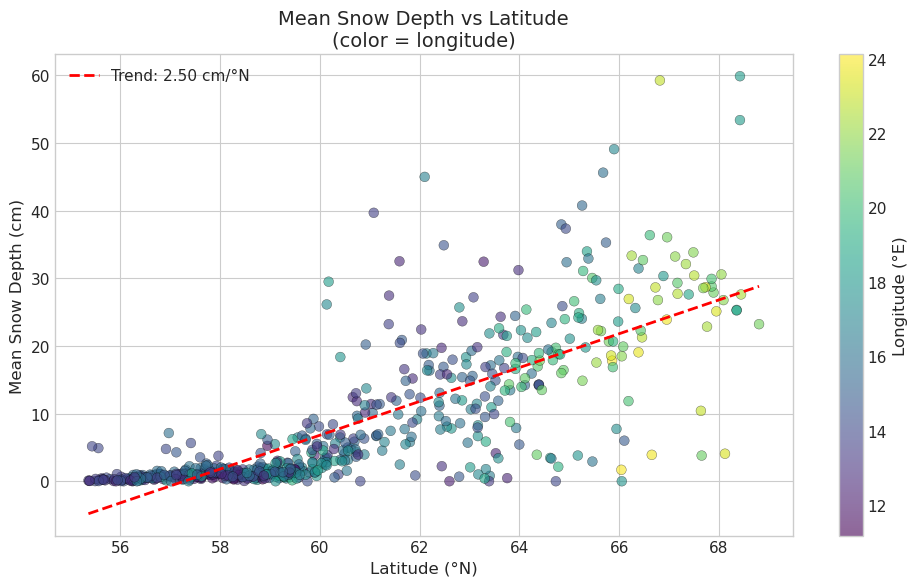

Latitudinal gradient: 2.50 cm per degree north


In [14]:
# Scatter plot: Latitude vs Mean Snow Depth
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(stations['lat'], stations['mean_snow'], c=stations['lon'], cmap='viridis', 
           s=50, alpha=0.6, edgecolors='black', linewidths=0.3)

# Add trend line
z = np.polyfit(stations['lat'], stations['mean_snow'], 1)
p = np.poly1d(z)
lat_range = np.linspace(stations['lat'].min(), stations['lat'].max(), 100)
ax.plot(lat_range, p(lat_range), 'r--', linewidth=2, label=f'Trend: {z[0]:.2f} cm/°N')

ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Mean Snow Depth (cm)')
ax.set_title('Mean Snow Depth vs Latitude\n(color = longitude)')
ax.legend()
plt.colorbar(ax.collections[0], label='Longitude (°E)')

plt.tight_layout()
plt.show()

print(f"Latitudinal gradient: {z[0]:.2f} cm per degree north")

---
## 5. Data Quality Analysis

In [15]:
# Missing values check
print("Missing Values:")
print("="*40)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values in any column!")
else:
    print(missing[missing > 0])

Missing Values:
No missing values in any column!


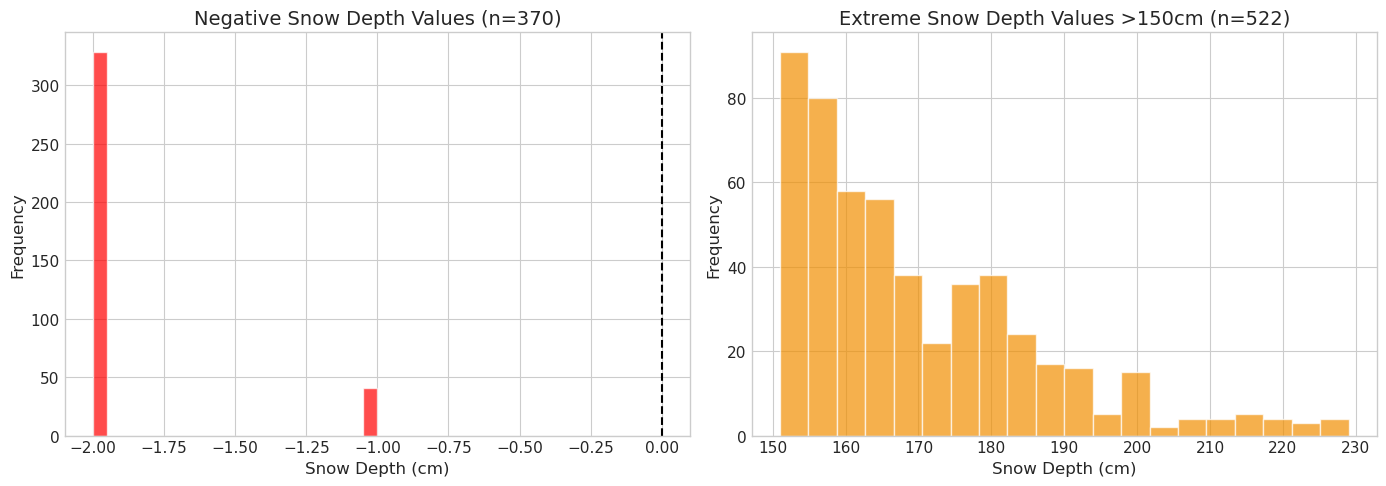


Anomalous Values Summary:
  Negative values: 370 (0.0274%)
  Values > 150cm: 522 (0.0387%)
  Values > 200cm: 29

  Stations with extreme values (>150cm):
    Almdalen: max 179 cm
    Gåltjärn: max 175 cm
    Gördalen D: max 151 cm
    Höglekardalen: max 152 cm
    Katterjåkk: max 229 cm
    Katterjåkk A: max 199 cm
    Kittelfjäll D: max 168 cm
    Klippen D: max 153 cm
    Mjölkbäcken: max 200 cm
    Storlien-Storvallen: max 185 cm
    Åsnorrbodarna: max 173 cm


In [16]:
# Anomalous values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Negative values
ax1 = axes[0]
negative = df[df['snow_depth_cm'] < 0]
ax1.hist(negative['snow_depth_cm'], bins=20, color='red', edgecolor='white', alpha=0.7)
ax1.set_xlabel('Snow Depth (cm)')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Negative Snow Depth Values (n={len(negative)})')
ax1.axvline(0, color='black', linestyle='--')

# Extreme values
ax2 = axes[1]
extreme = df[df['snow_depth_cm'] > 150]
ax2.hist(extreme['snow_depth_cm'], bins=20, color=COLORS['accent'], edgecolor='white', alpha=0.7)
ax2.set_xlabel('Snow Depth (cm)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Extreme Snow Depth Values >150cm (n={len(extreme)})')

plt.tight_layout()
plt.show()

print(f"\nAnomalous Values Summary:")
print(f"  Negative values: {len(negative)} ({100*len(negative)/len(df):.4f}%)")
print(f"  Values > 150cm: {len(extreme)} ({100*len(extreme)/len(df):.4f}%)")
print(f"  Values > 200cm: {len(df[df['snow_depth_cm'] > 200])}")

if len(extreme) > 0:
    print(f"\n  Stations with extreme values (>150cm):")
    for station in extreme['station_name'].unique():
        max_val = extreme[extreme['station_name']==station]['snow_depth_cm'].max()
        print(f"    {station}: max {max_val:.0f} cm")

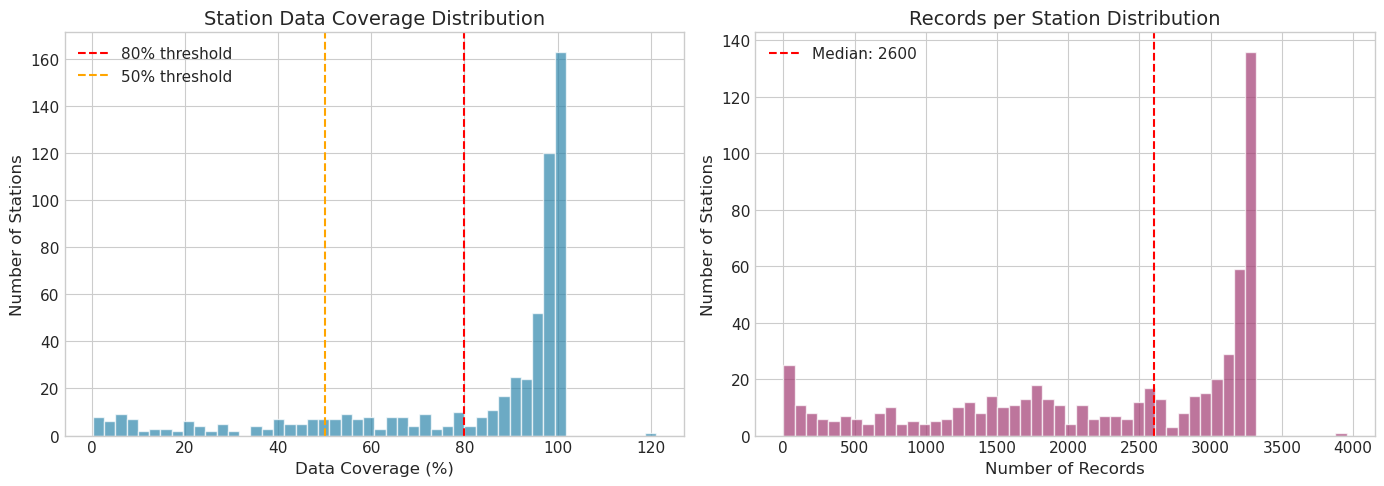


Coverage Statistics:
  Stations with >90% coverage: 384
  Stations with >80% coverage: 425
  Stations with >50% coverage: 510
  Mean coverage: 81.0%


In [17]:
# Station data coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate coverage
stations['days_span'] = (stations['last_date'] - stations['first_date']).dt.days + 1
stations['coverage'] = stations['n_records'] / stations['days_span']

# Coverage distribution
ax1 = axes[0]
ax1.hist(stations['coverage'] * 100, bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.7)
ax1.set_xlabel('Data Coverage (%)')
ax1.set_ylabel('Number of Stations')
ax1.set_title('Station Data Coverage Distribution')
ax1.axvline(80, color='red', linestyle='--', label='80% threshold')
ax1.axvline(50, color='orange', linestyle='--', label='50% threshold')
ax1.legend()

# Records per station
ax2 = axes[1]
ax2.hist(stations['n_records'], bins=50, color=COLORS['secondary'], edgecolor='white', alpha=0.7)
ax2.set_xlabel('Number of Records')
ax2.set_ylabel('Number of Stations')
ax2.set_title('Records per Station Distribution')
ax2.axvline(stations['n_records'].median(), color='red', linestyle='--', 
            label=f"Median: {stations['n_records'].median():.0f}")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nCoverage Statistics:")
print(f"  Stations with >90% coverage: {(stations['coverage'] > 0.9).sum()}")
print(f"  Stations with >80% coverage: {(stations['coverage'] > 0.8).sum()}")
print(f"  Stations with >50% coverage: {(stations['coverage'] > 0.5).sum()}")
print(f"  Mean coverage: {stations['coverage'].mean()*100:.1f}%")

---
## 6. Extreme Events Analysis

Analysis of extreme snow events for the anomaly detection task (Head D).

In [18]:
# Calculate daily snow change per station
df_sorted = df.sort_values(['station_name', 'date'])
df_sorted['snow_change'] = df_sorted.groupby('station_name')['snow_depth_cm'].diff()

# Define extreme events
heavy_snowfall = df_sorted[df_sorted['snow_change'] > 30]  # >30cm in 1 day
rapid_melt = df_sorted[df_sorted['snow_change'] < -20]     # >20cm loss in 1 day
extreme_depth = df_sorted[df_sorted['snow_depth_cm'] > 150] # >150cm total

print("Extreme Events Summary:")
print("="*50)
print(f"Heavy snowfall events (>30 cm/day): {len(heavy_snowfall)}")
print(f"Rapid melt events (>20 cm/day loss): {len(rapid_melt)}")
print(f"Extreme depth events (>150 cm): {len(extreme_depth)}")
print(f"\nTotal potential anomalies: {len(heavy_snowfall) + len(rapid_melt)}")
print(f"Anomaly rate: {100*(len(heavy_snowfall) + len(rapid_melt))/len(df):.3f}%")

Extreme Events Summary:
Heavy snowfall events (>30 cm/day): 347
Rapid melt events (>20 cm/day loss): 917
Extreme depth events (>150 cm): 522

Total potential anomalies: 1264
Anomaly rate: 0.094%


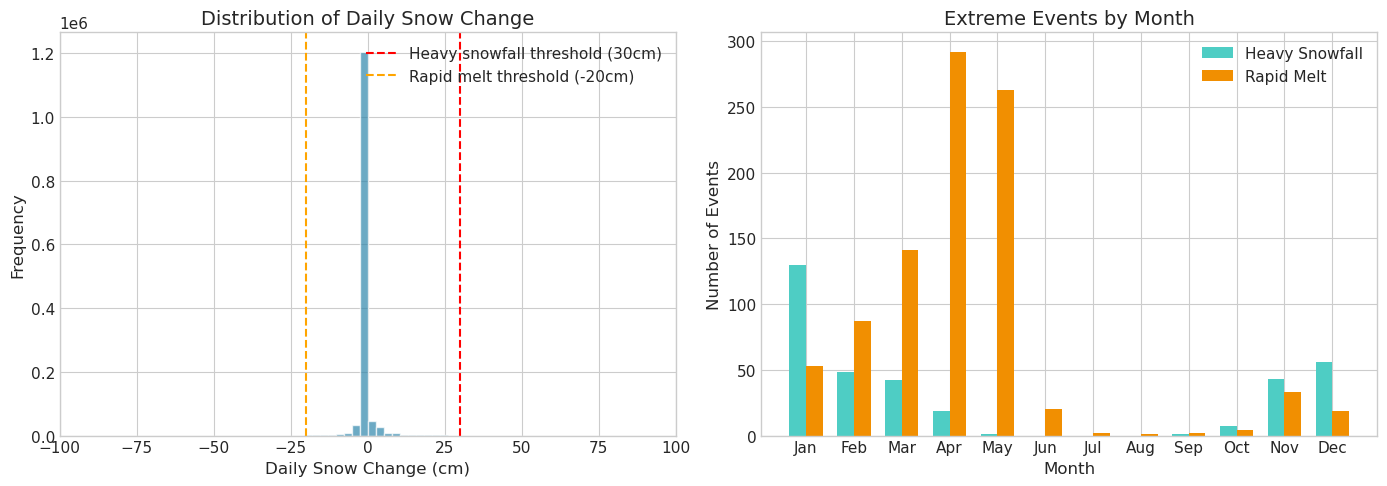

In [19]:
# Snow change distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ax1 = axes[0]
valid_changes = df_sorted['snow_change'].dropna()
ax1.hist(valid_changes, bins=100, color=COLORS['primary'], edgecolor='white', alpha=0.7)
ax1.set_xlabel('Daily Snow Change (cm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Daily Snow Change')
ax1.axvline(30, color='red', linestyle='--', label='Heavy snowfall threshold (30cm)')
ax1.axvline(-20, color='orange', linestyle='--', label='Rapid melt threshold (-20cm)')
ax1.set_xlim(-100, 100)
ax1.legend()

# Extreme events by month
ax2 = axes[1]
heavy_by_month = heavy_snowfall.groupby('month').size()
melt_by_month = rapid_melt.groupby('month').size()

x = np.arange(12)
width = 0.35
ax2.bar(x - width/2, [heavy_by_month.get(m+1, 0) for m in range(12)], width, 
        label='Heavy Snowfall', color=COLORS['snow'])
ax2.bar(x + width/2, [melt_by_month.get(m+1, 0) for m in range(12)], width, 
        label='Rapid Melt', color=COLORS['accent'])
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Events')
ax2.set_title('Extreme Events by Month')
ax2.set_xticks(x)
ax2.set_xticklabels(months)
ax2.legend()

plt.tight_layout()
plt.show()

In [20]:
# Top extreme events
print("Top 10 Heavy Snowfall Events:")
print("-"*60)
top_snowfall = heavy_snowfall.nlargest(10, 'snow_change')[['date', 'station_name', 'snow_change', 'snow_depth_cm', 'latitude']]
for i, (_, row) in enumerate(top_snowfall.iterrows(), 1):
    print(f"{i:2d}. {row['date'].date()} @ {row['station_name']}: +{row['snow_change']:.0f} cm (total: {row['snow_depth_cm']:.0f} cm)")

print("\nTop 10 Rapid Melt Events:")
print("-"*60)
top_melt = rapid_melt.nsmallest(10, 'snow_change')[['date', 'station_name', 'snow_change', 'snow_depth_cm', 'latitude']]
for i, (_, row) in enumerate(top_melt.iterrows(), 1):
    print(f"{i:2d}. {row['date'].date()} @ {row['station_name']}: {row['snow_change']:.0f} cm (remaining: {row['snow_depth_cm']:.0f} cm)")

Top 10 Heavy Snowfall Events:
------------------------------------------------------------
 1. 2018-03-13 @ Sorsele: +125 cm (total: 125 cm)
 2. 2018-04-01 @ Ankarvattnet D: +107 cm (total: 107 cm)
 3. 2018-03-10 @ Hillsand: +106 cm (total: 106 cm)
 4. 2015-04-30 @ Almdalen: +103 cm (total: 103 cm)
 5. 2018-03-31 @ Norrby: +101 cm (total: 106 cm)
 6. 2018-04-15 @ Norrby: +99 cm (total: 99 cm)
 7. 2018-01-31 @ Norrby: +94 cm (total: 97 cm)
 8. 2018-03-15 @ Norrby: +92 cm (total: 112 cm)
 9. 2018-02-15 @ Norrby: +86 cm (total: 92 cm)
10. 2023-04-01 @ Svanstein: +84 cm (total: 85 cm)

Top 10 Rapid Melt Events:
------------------------------------------------------------
 1. 2015-04-21 @ Almdalen: -135 cm (remaining: 0 cm)
 2. 2020-06-01 @ Almdalen: -114 cm (remaining: 0 cm)
 3. 2018-05-13 @ Almdalen: -113 cm (remaining: 0 cm)
 4. 2015-06-06 @ Almdalen: -103 cm (remaining: 0 cm)
 5. 2023-05-23 @ Almdalen: -102 cm (remaining: 0 cm)
 6. 2018-04-01 @ Norrby: -101 cm (remaining: 5 cm)
 7. 2018

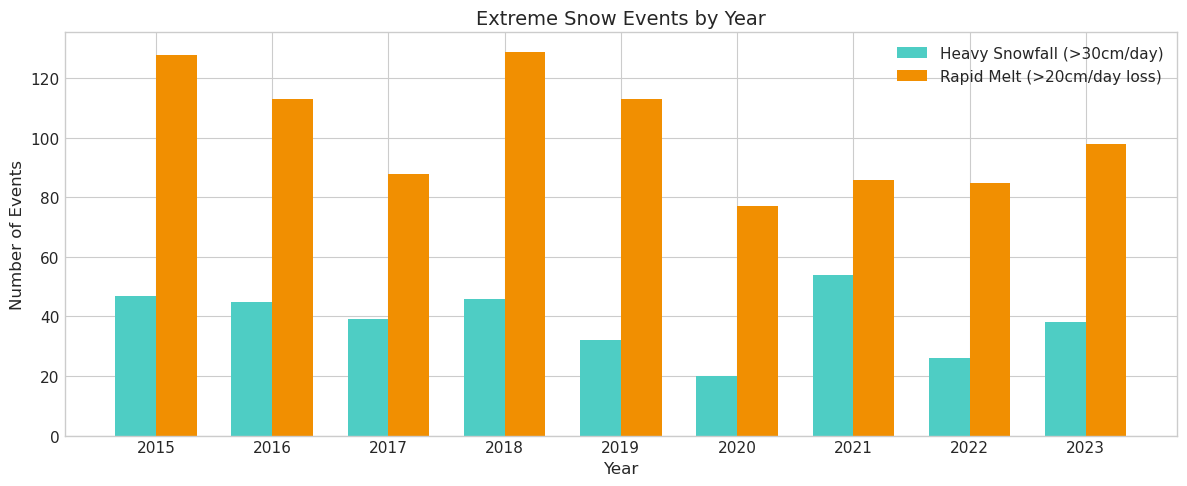

In [21]:
# Extreme events by year
fig, ax = plt.subplots(figsize=(12, 5))

heavy_by_year = heavy_snowfall.groupby('year').size()
melt_by_year = rapid_melt.groupby('year').size()

years = range(2015, 2024)
x = np.arange(len(years))
width = 0.35

ax.bar(x - width/2, [heavy_by_year.get(y, 0) for y in years], width, 
       label='Heavy Snowfall (>30cm/day)', color=COLORS['snow'])
ax.bar(x + width/2, [melt_by_year.get(y, 0) for y in years], width, 
       label='Rapid Melt (>20cm/day loss)', color=COLORS['accent'])

ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')
ax.set_title('Extreme Snow Events by Year')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()

plt.tight_layout()
plt.show()

---
## 7. Train/Val/Test Split Preview

In [22]:
# Preview of data splits
train = df[df['year'].between(2015, 2021)]
val = df[df['year'] == 2022]
test = df[df['year'] == 2023]

print("Train/Val/Test Split Summary:")
print("="*60)
print(f"{'Split':<10} {'Years':<12} {'Records':>12} {'Stations':>10} {'% Total':>10}")
print("-"*60)
print(f"{'Train':<10} {'2015-2021':<12} {len(train):>12,} {train['station_name'].nunique():>10} {100*len(train)/len(df):>9.1f}%")
print(f"{'Val':<10} {'2022':<12} {len(val):>12,} {val['station_name'].nunique():>10} {100*len(val)/len(df):>9.1f}%")
print(f"{'Test':<10} {'2023':<12} {len(test):>12,} {test['station_name'].nunique():>10} {100*len(test)/len(df):>9.1f}%")
print("-"*60)
print(f"{'Total':<10} {'2015-2023':<12} {len(df):>12,} {df['station_name'].nunique():>10} {'100.0%':>10}")

Train/Val/Test Split Summary:
Split      Years             Records   Stations    % Total
------------------------------------------------------------
Train      2015-2021       1,046,977        600      77.6%
Val        2022              154,294        485      11.4%
Test       2023              147,890        465      11.0%
------------------------------------------------------------
Total      2015-2023       1,349,161        602     100.0%


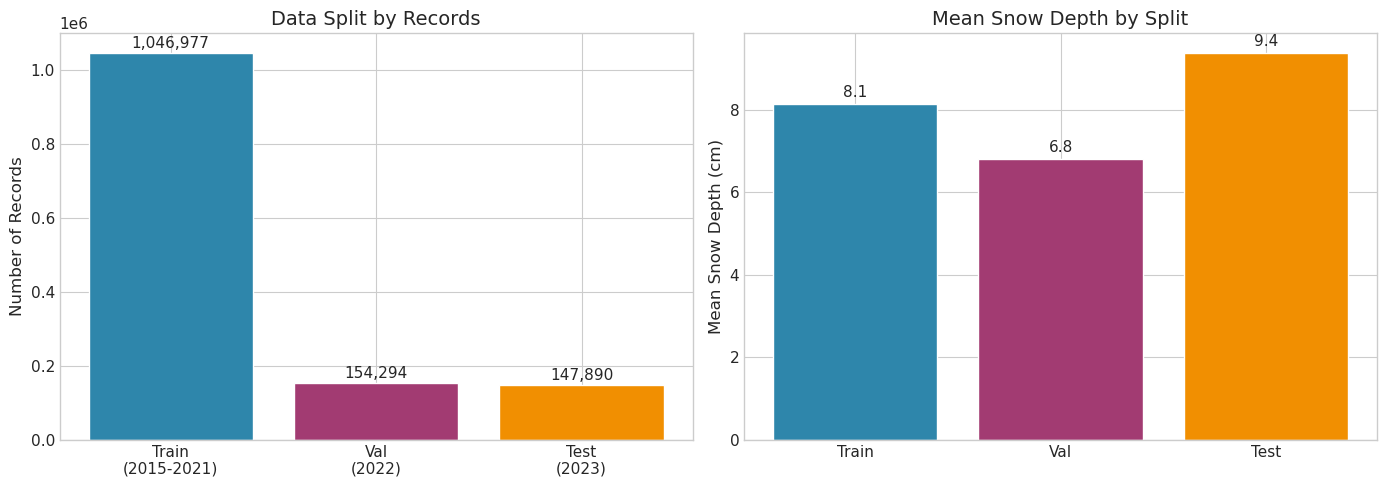

In [23]:
# Visualize splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records by split
ax1 = axes[0]
splits = ['Train\n(2015-2021)', 'Val\n(2022)', 'Test\n(2023)']
sizes = [len(train), len(val), len(test)]
colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]
bars = ax1.bar(splits, sizes, color=colors, edgecolor='white')
ax1.set_ylabel('Number of Records')
ax1.set_title('Data Split by Records')
for bar, size in zip(bars, sizes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, f'{size:,}', 
             ha='center', va='bottom', fontsize=11)

# Snow statistics by split
ax2 = axes[1]
split_stats = {
    'Train': train['snow_depth_cm'].mean(),
    'Val': val['snow_depth_cm'].mean(),
    'Test': test['snow_depth_cm'].mean()
}
bars = ax2.bar(split_stats.keys(), split_stats.values(), color=colors, edgecolor='white')
ax2.set_ylabel('Mean Snow Depth (cm)')
ax2.set_title('Mean Snow Depth by Split')
for bar, val_mean in zip(bars, split_stats.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val_mean:.1f}', 
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [24]:
# Check for data leakage - station overlap
train_stations = set(train['station_name'].unique())
val_stations = set(val['station_name'].unique())
test_stations = set(test['station_name'].unique())

print("Station Overlap Analysis:")
print("="*50)
print(f"Train stations: {len(train_stations)}")
print(f"Val stations: {len(val_stations)}")
print(f"Test stations: {len(test_stations)}")
print(f"\nStations in all three splits: {len(train_stations & val_stations & test_stations)}")
print(f"Stations only in train: {len(train_stations - val_stations - test_stations)}")
print(f"\nNote: Temporal split (by year) avoids data leakage while allowing")
print(f"      the model to learn station-specific patterns.")

Station Overlap Analysis:
Train stations: 600
Val stations: 485
Test stations: 465

Stations in all three splits: 461
Stations only in train: 114

Note: Temporal split (by year) avoids data leakage while allowing
      the model to learn station-specific patterns.


---
## Summary & Next Steps

### Key Findings:
1. **Dataset Size**: 1.35M records from 602 stations (2015-2023)
2. **Snow Patterns**: Clear seasonal and latitudinal gradients
3. **Data Quality**: 86.5% approved quality, 370 negative values to clean
4. **Extreme Events**: ~0.09% anomaly rate (class imbalance!)

### Next Steps:
1. **Data Cleaning**: Remove negative values, handle outliers
2. **Feature Engineering**: Add weather data, cyclical time features
3. **Sequence Creation**: Build 30-day input windows
4. **Preprocessing**: Normalize features, create train/val/test splits
5. **Model Training**: Train multi-task model with all three heads

In [25]:
print("Data exploration complete!")
print(f"\nDataset ready for preprocessing:")
print(f"  - File: ../data/raw/smhi_snow.csv")
print(f"  - Records: {len(df):,}")
print(f"  - Stations: {df['station_name'].nunique()}")
print(f"  - Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Data exploration complete!

Dataset ready for preprocessing:
  - File: ../data/raw/smhi_snow.csv
  - Records: 1,349,161
  - Stations: 602
  - Date range: 2015-01-01 to 2023-12-31
